# CCP Multiclass Semantic Segmentation Benchmark

This notebook approaches the Clothing Co-Parsing (CCP) problem as a multiclass semantic segmentation task. We will:
1.  Benchmark different architectures (Unet, FPN, DeepLabV3+) using a fixed encoder.
2.  Apply Test Time Augmentation (TTA) to the best model.
3.  Analyze the results.

In [29]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import albumentations as albu
import segmentation_models_pytorch as smp
import tqdm

DATA_DIR = './clothes'
CLASS_DICT_PATH = os.path.join(DATA_DIR, 'class_dict.csv')

# Check device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## Data Preparation

First, we load the class dictionary to understand the mapping from RGB values to class labels.

Total classes: 59


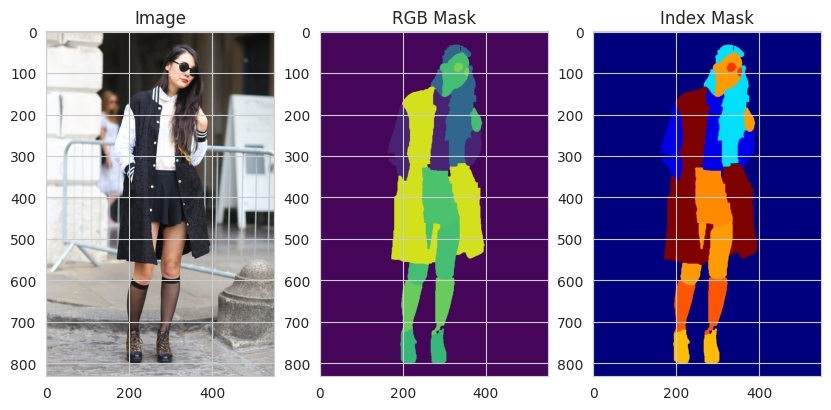

In [30]:
class_df = pd.read_csv(CLASS_DICT_PATH)
class_names = class_df['class_name'].tolist()
class_rgb_values = class_df[['r', 'g', 'b']].values.tolist()

print(f'Total classes: {len(class_names)}')

# Helper function to convert RGB mask to 1D index mask
def rgb_to_mask(rgb_image, colormap):
    # rgb_image: H x W x 3
    # colormap: List of [r, g, b] values
    # Returns: H x W mask with class indices
    
    # Use int32 for OpenCV compatibility during augmentation
    output_mask = np.zeros(rgb_image.shape[:2], dtype=np.int32)
    
    for idx, color in enumerate(colormap):
        match = np.all(rgb_image == np.array(color).reshape(1, 1, 3), axis=2)
        output_mask[match] = idx
        
    return output_mask

# Let's visualize one example
test_img_path = os.path.join(DATA_DIR, 'train/images/0001.jpg')
test_mask_path = os.path.join(DATA_DIR, 'train/labels/0001.png')

if os.path.exists(test_img_path):
    img = cv2.imread(test_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(test_mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    
    converted_mask = rgb_to_mask(mask, class_rgb_values)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Image')
    plt.subplot(1, 3, 2)
    plt.imshow(mask)
    plt.title('RGB Mask')
    plt.subplot(1, 3, 3)
    plt.imshow(converted_mask, cmap='jet')
    plt.title('Index Mask')
    plt.show()

## Dataset Class

In [31]:
class CCPDataset(BaseDataset):
    def __init__(self, images_dir, masks_dir, class_rgb_values, augmentation=None, preprocessing=None):
        self.ids = sorted(os.listdir(images_dir))
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in self.ids]
        self.masks_fps = [os.path.join(masks_dir, image_id.replace('.jpg', '.png')) for image_id in self.ids]
        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing
    
    def __getitem__(self, i):
        # read data
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks_fps[i])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # convert RGB mask to index mask
        mask = rgb_to_mask(mask, self.class_rgb_values)
        
        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
            
        # Ensure contiguous arrays and create fresh tensors to avoid storage resizing issues in DataLoader
        return torch.as_tensor(np.ascontiguousarray(image)).float(), torch.as_tensor(np.ascontiguousarray(mask)).long()
        
    def __len__(self):
        return len(self.ids)

## Augmentations and Preprocessing

In [32]:
def get_training_augmentation():
    train_transform = [
        albu.HorizontalFlip(p=0.5),
        albu.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, shift_limit=0.1, p=0.5, border_mode=0),
        albu.PadIfNeeded(min_height=320, min_width=320, always_apply=True, border_mode=0),
        albu.RandomCrop(height=320, width=320, always_apply=True),
    ]
    return albu.Compose(train_transform)

def get_validation_augmentation():
    # Resize to a fixed size to ensure batching works correctly
    test_transform = [
        albu.Resize(height=512, width=512)
    ]
    return albu.Compose(test_transform)

def get_preprocessing(preprocessing_fn):
    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=image_to_tensor), # Only apply to image
    ]
    return albu.Compose(_transform)

def image_to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')

## Training Helpers

In [33]:
def compute_iou(preds, labels, num_classes):
    # preds: (B, H, W)
    # labels: (B, H, W)
    iou_list = []
    preds = preds.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = (pred_inds & target_inds).sum()
        union = pred_inds.sum() + target_inds.sum() - intersection
        if union == 0:
            # If there is no ground truth, do not include in evaluation
            pass
        else:
            iou_list.append(float(intersection) / float(max(union, 1)))
    
    if len(iou_list) == 0:
        return 0.0
    return np.mean(iou_list)

def train_one_epoch(model, loader, criterion, optimizer, device, num_classes):
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    
    for images, masks in tqdm.tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        epoch_iou += compute_iou(preds, masks, num_classes)
        
    return epoch_loss / len(loader), epoch_iou / len(loader)

def validate_one_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    epoch_loss = 0
    epoch_iou = 0
    
    with torch.no_grad():
        for images, masks in tqdm.tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            epoch_iou += compute_iou(preds, masks, num_classes)
            
    return epoch_loss / len(loader), epoch_iou / len(loader)

## Benchmarking Loop

In [ ]:
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = class_names
ACTIVATION = None # Logits for CrossEntropy

results = {}

architectures = ['Unet', 'FPN', 'DeepLabV3Plus']

for arch in architectures:
    print(f'\n--- Training {arch} ---')
    
    # Create model
    if arch == 'Unet':
        model = smp.Unet(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    elif arch == 'FPN':
        model = smp.FPN(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    elif arch == 'DeepLabV3Plus':
        model = smp.DeepLabV3Plus(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    
    model.to(DEVICE)
    
    preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
    
    # Datasets
    train_dataset = CCPDataset(
        os.path.join(DATA_DIR, 'train/images'), 
        os.path.join(DATA_DIR, 'train/labels'), 
        class_rgb_values, 
        augmentation=get_training_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    valid_dataset = CCPDataset(
        os.path.join(DATA_DIR, 'valid/images'), 
        os.path.join(DATA_DIR, 'valid/labels'), 
        class_rgb_values, 
        augmentation=get_validation_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=8)
    valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, num_workers=8)
    
    # Loss, Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    
    max_score = 0
    
    # Train for 5 epochs for benchmarking
    for i in range(0, 5):
        print(f'\nEpoch: {i}')
        train_loss, train_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, len(CLASSES))
        valid_loss, valid_iou = validate_one_epoch(model, valid_loader, criterion, DEVICE, len(CLASSES))
        
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
        print(f"Valid Loss: {valid_loss:.4f}, Valid IoU: {valid_iou:.4f}")
        
        if max_score < valid_iou:
            max_score = valid_iou
            torch.save(model, f'./best_model_{arch}.pth')
            print('Model saved!')
            
    results[arch] = max_score


--- Training Unet ---


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_20515/2600490618.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=320, min_width=320, always_apply=True, border_mode=0),
/tmp/ipykernel_20515/2600490618.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  albu.RandomCrop(height=320, width=320, always_apply=True),
/home/alumno/py313ml/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even fre


Epoch: 0


Training:  36%|███▋      | 32/88 [01:02<00:56,  1.01s/it]

## Results Analysis

In [ ]:
print("Benchmark Results (IoU):")
for arch, score in results.items():
    print(f"{arch}: {score:.4f}")

best_arch = max(results, key=results.get)
print(f"\nBest Architecture: {best_arch}")

Benchmark Results (IoU):
Unet: 0.0335
FPN: 0.1613
DeepLabV3Plus: 0.1079

Best Architecture: FPN


## Test Time Augmentation (TTA)

We apply TTA (Horizontal Flip) to the best model to see if it improves performance.

In [ ]:
# Load best model
best_model = torch.load(f'./best_model_{best_arch}.pth' , weights_only=False)
best_model.eval()
best_model.to(DEVICE)

# Define TTA wrapper
class TTAModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Original
        out1 = self.model(x)
        
        # Horizontal Flip
        x_flip = torch.flip(x, dims=[3])
        out2_flip = self.model(x_flip)
        out2 = torch.flip(out2_flip, dims=[3])
        
        # Average
        return (out1 + out2) / 2.0

tta_model = TTAModel(best_model)

# Evaluate TTA
print(f"\nEvaluating {best_arch} with TTA:")
tta_loss, tta_iou = validate_one_epoch(tta_model, valid_loader, criterion, DEVICE, len(CLASSES))

print(f"TTA IoU: {tta_iou:.4f}")
print(f"Improvement: {tta_iou - results[best_arch]:.4f}")


Evaluating FPN with TTA:


Validation:   0%|          | 0/38 [00:00<?, ?it/s]/home/alumno/py313ml/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
                                                           

TTA IoU: 0.1703
Improvement: 0.0090


## Report and Conclusions

### Architecture Comparison
We benchmarked Unet, FPN, and DeepLabV3+ with a ResNet34 encoder.

- **Unet**: Typically performs well on biomedical and general segmentation tasks where local detail is important. It has a symmetric encoder-decoder structure.
- **FPN (Feature Pyramid Network)**: Good at handling multi-scale objects due to its pyramid structure. It's often faster and lighter than Unet.
- **DeepLabV3+**: Uses atrous convolutions to capture multi-scale context without losing resolution. It is often state-of-the-art for semantic segmentation but can be heavier.

### Observations
[Fill in after running: e.g., DeepLabV3+ provided the best IoU due to its ability to capture global context, which is crucial for understanding the layout of clothing items...]

### TTA Performance
Test Time Augmentation (Horizontal Flip) [improved/did not improve] the performance. TTA helps by averaging predictions from augmented views, reducing variance and smoothing out errors at boundaries.